Please run **Figure4a_Covid_data_analysis.ipynb** first to generate the necessary data

In [ ]:
import os
# Change cwd to the notebook's directory for VS Code
try:
    notebook_path = globals()['__vsc_ipynb_file__']
    notebook_dir = os.path.dirname(notebook_path)
    os.chdir(notebook_dir)
    print(f"Changed directory to: {notebook_dir}")
except:
    print("Could not find notebook path. Running from:", os.getcwd())


Changed directory to: /lustre/groups/imm01/workspace/yang/DextraDemixer/experiments/Kocher_SARS-CoV-2


In [2]:
%load_ext autoreload
%autoreload 2

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sb

import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.stats import pearsonr, t, wilcoxon, ttest_ind, ttest_rel

In [4]:
import scanpy as sc
import logomaker as lm
import matplotlib.patches as patches

In [5]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [6]:
def mean_ci_t_interval(x, confidence=0.95):
    x = x.dropna()
    n = len(x)
    mean = x.mean()

    alpha = 1 - confidence
    q = 1 - alpha / 2  # for 95% CI: 1 - 0.05/2 = 0.975

    tcrit = t.ppf(q, df=n - 1)
    se = x.std(ddof=1) / np.sqrt(n)
    ci = tcrit * se

    ci_low = mean - ci
    ci_high = mean + ci

    return f"{mean:.3f} [{ci_low:.3f}, {ci_high:.3f}]"

# Settings

In [7]:
TEXT_WIDTH = 6.7261  # in
DPI = 360

def set_font_size(font_size):
    plt.rc('font', size=font_size)          # controls default text sizes
    plt.rc('axes', titlesize=font_size)     # fontsize of the axes title
    plt.rc('axes', labelsize=font_size)     # fontsize of the x and y labels
    plt.rc('xtick', labelsize=font_size)    # fontsize of the tick labels
    plt.rc('ytick', labelsize=font_size)    # fontsize of the tick labels
    plt.rc('legend', fontsize=font_size, title_fontsize=font_size)    # legend fontsize
    plt.rc('figure', titlesize=font_size)   # fontsize of the figure title

In [ ]:
sb.set(context='paper', style='whitegrid')
plt.rc('grid', linewidth=0.3)
sb.set_palette('colorblind')
set_font_size(6)

In [ ]:
epitopes = ['LTDEMIAQY', 'YLQPRTFLL']
model = 'Base'

## Colors

In [ ]:
palette = { 'ITRAP': "#ffa52e", 'ICON': "#ffeb11", 'BEAM': "#02c102",
           'DextraDemixer': "#24c8c8", 'DextraDemixer+neg.': "#0f83b8", 'DextraDemixer+clone': "#0A44D5", 'DextraDemixer+neg.+clone': "#8900bf",}
palette_epitopes = { 'LTD': "#0ac940", 'YLQ': "#157E00", }
palette_epitopes_ext = {'LTD_spec': palette_epitopes['LTD'], 'LTD_unspec': 'lightgrey', 'YLQ_spec': palette_epitopes['YLQ'], 'YLQ_unspec': 'lightgrey',}
palette_epitopes_ext2 = {'LTD': {'LTD': palette_epitopes['LTD'], 'Random': 'lightgray'}, 'YLQ': {'YLQ': palette_epitopes['YLQ'], 'Random': 'lightgray'}}
palette_epitopes_ext3 = {'LTD/YLQ': "#00a31e", 'any': 'lightgray'}


# Load data
## UMAP

In [11]:
adata = sc.read('results/kocher/adata_processed.h5ad')

## TULIP-Prediction

In [12]:
df_prediction = pd.read_csv('results/kocher/ePytope_prediction.csv', index_col=0)

## Distances

In [13]:
df_dist_pairs = pd.read_csv('results/kocher/pairwise_distances.csv', index_col=0)
df_dist_pairs['sameSpec'] = df_dist_pairs['sameSpec'].str.lower() 

/tmp/ipykernel_2070539/1407241643.py:1: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  df_dist_pairs = pd.read_csv('results/kocher/pairwise_distances.csv', index_col=0)


In [14]:
df_nn_ltd = pd.read_csv('results/kocher/tcrdist_stacked_ltd.csv', index_col=0)
df_nn_ltd = df_nn_ltd[df_nn_ltd.index.isin(['Random', '1.0'])]
df_nn_ltd.index = df_nn_ltd.index.map({'Random': 'Random', '1.0': 'LTD'})
df_nn_ltd = df_nn_ltd.reset_index()
df_nn_ltd.columns = ['Group', 'Other', 'LTD']
df_nn_ltd = df_nn_ltd[['Group', 'LTD']]
df_nn_ltd

,Group,LTD
0,Random,0.00745
1,LTD,0.27451


In [15]:
df_nn_ylq= pd.read_csv('results/kocher/tcrdist_stacked_ylq.csv', index_col=0)
df_nn_ylq = df_nn_ylq[df_nn_ylq.index.isin(['Random', '1.0'])]
df_nn_ylq.index = df_nn_ylq.index.map({'Random': 'Random', '1.0': 'YLQ'})
df_nn_ylq = df_nn_ylq.reset_index()
df_nn_ylq.columns = ['Group', 'Other', 'YLQ']
df_nn_ylq = df_nn_ylq[['Group', 'YLQ']]
df_nn_ylq

,Group,YLQ
0,Random,0.002971
1,YLQ,0.689189


In [ ]:
df_nn_ylq.loc[1, 'YLQ'] - df_nn_ylq.loc[0, 'YLQ']

np.float64(0.6862184803780669)

In [ ]:
df_nn_ltd.loc[1, 'LTD'] - df_nn_ltd.loc[0, 'LTD']

np.float64(0.2670599079001788)

## Purity

In [18]:
df_purity = pd.read_csv('results/kocher/clonal_purity.csv', index_col=0)
#df_purity['Name'] = df_purity['Name'].replace({'Positive': 'Specific', 
#                                                'Positive Expanded': 'Specific expanded'})
df_purity['Expanded'] = ['All', 'Expanded', 'All', 'Expanded']
df_purity['Specific'] = ['any', 'any', 'LTD/YLQ', 'LTD/YLQ']

In [19]:
df_purity

,Name,Purity,Expanded,Specific
0,All,0.999503,All,any
1,Expanded,0.997219,Expanded,any
2,Positive,0.942244,All,LTD/YLQ
3,Postive Expanded,0.873064,Expanded,LTD/YLQ


In [ ]:
df_purity_all = pd.read_csv('results/kocher/purity_expansion_all.csv', index_col=0)

## Performance

In [ ]:
results_class = pd.read_csv('results/kocher/classification_metrics.csv', index_col=0)
results_class = results_class[results_class['Metric'].isin(['F1-Score', 'Accuracy', 'Precision', 'Recall'])]
results_class = results_class[results_class['Baseline']=='paper']
results_class['Metric'] = results_class['Metric'].replace({'F1-Score': 'F1', 'Accuracy': 'Acc'})
results_class['Method'] = results_class['Method'].replace({'Base': 'DextraDemixer', 'CloneModel': 'DextraDemixer+clone'})
results_class

,Method,Epitope,Experiment,Baseline,Metric,Value
28,DextraDemixer,LTD,first,paper,F1,1.000000
29,DextraDemixer,LTD,first,paper,Acc,1.000000
30,DextraDemixer,LTD,first,paper,Precision,1.000000
31,DextraDemixer,LTD,first,paper,Recall,1.000000
32,DextraDemixer,YLQ,first,paper,F1,1.000000
33,DextraDemixer,YLQ,first,paper,Acc,1.000000
34,DextraDemixer,YLQ,first,paper,Precision,1.000000
35,DextraDemixer,YLQ,first,paper,Recall,1.000000
64,DextraDemixer,LTD,second,paper,F1,0.916031
65,DextraDemixer,LTD,second,paper,Acc,0.986058


In [23]:
results_class[(results_class['Metric']=='F1')].groupby(['Method', 'Epitope'])['Value'].min()

Method               Epitope
DextraDemixer        LTD        0.808989
                     YLQ        0.887218
DextraDemixer+clone  LTD        0.868327
                     YLQ        0.911765
Name: Value, dtype: float64

In [24]:
results_class[results_class["Metric"] == "F1"].groupby("Method")["Value"].apply(mean_ci_t_interval)

Method
DextraDemixer          0.926 [0.849, 1.002]
DextraDemixer+clone    0.947 [0.893, 1.001]
Name: Value, dtype: object

In [25]:
np.diff(results_class[(results_class['Metric']=='F1')].groupby(['Method'])['Value'].mean())

array([0.02104833])

In [26]:
tmp = results_class[(results_class['Metric']=='F1')]
val1 = tmp[tmp['Method']=='DextraDemixer']['Value'].values
val2 = tmp[tmp['Method']=='DextraDemixer+clone']['Value'].values
wilcoxon(val1, val2)

WilcoxonResult(statistic=np.float64(0.0), pvalue=np.float64(0.25))

In [ ]:
results_score = pd.read_csv('results/kocher/separation_metrics.csv', index_col=0)
results_score = results_score[results_score['Baseline']=='paper']
results_score['Method'] = results_score['Method'].replace({'Base': 'DextraDemixer', 'CloneModel': 'DextraDemixer+clone'})

In [28]:
results_score[(results_score['Metric']=='APS')].groupby(['Method', 'Epitope'])['Value'].min()

Method               Epitope
DextraDemixer        LTD        0.956786
                     YLQ        0.928802
DextraDemixer+clone  LTD        0.976646
                     YLQ        0.934545
Name: Value, dtype: float64

In [29]:
results_score[results_score["Metric"] == "APS"].groupby("Method")["Value"].apply(mean_ci_t_interval)

Method
DextraDemixer          0.972 [0.943, 1.002]
DextraDemixer+clone    0.980 [0.955, 1.006]
Name: Value, dtype: object

In [30]:
np.diff(results_score[(results_score['Metric']=='APS')].groupby(['Method'])['Value'].mean())

array([0.00793754])

In [31]:
tmp = results_score[(results_score['Metric']=='APS')]
val1 = tmp[tmp['Method']=='DextraDemixer']['Value'].values
val2 = tmp[tmp['Method']=='DextraDemixer+clone']['Value'].values
wilcoxon(val1, val2)

WilcoxonResult(statistic=np.float64(0.0), pvalue=np.float64(0.25))

## Motifs

In [32]:
sequences = {n.upper(): pd.read_csv(f'results/kocher/selected_sequences_{n}.csv', index_col=0) for n in ['ltd', 'ylq']}

In [33]:
df_precision_ltd = pd.read_csv('results/kocher/precision_motif_query_ltd.csv', index_col=0)
df_precision_ltd['Method'] = df_precision_ltd['Method'].replace({'V-J': 'V29-1\nJ2-7',
                                                                 'V-J+GWPY': 'V29-1\nJ2-7\nGWPY'})
df_precision_ltd

,Method,Precision,n_pos
0,All,0.001897,133
4,V29-1\nJ2-7,0.020253,8
2,GWP,0.304348,7
1,WPY,0.583333,7
3,GWPY,0.875000,7
5,V29-1\nJ2-7\nGWPY,1.000000,7


In [ ]:
df_precision_ylq = pd.read_csv('results/kocher/precision_motif_query_ylq.csv', index_col=0)
df_precision_ylq['Method'] = df_precision_ylq['Method'].replace({'J-gene': 'J2-2',
                                                                 'J+NTGELF': 'J2-2\nNTGELF'})
df_precision_ylq = df_precision_ylq[df_precision_ylq['Method']!='J2-2\nNTGELF'].copy()

In [ ]:
df_precision_ylq = df_precision_ylq[df_precision_ylq['Method']!='J2-2']

# Plotting functions
## Umaps

/tmp/ipykernel_2070539/4021991066.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plot.legend(loc='upper right', frameon=False)


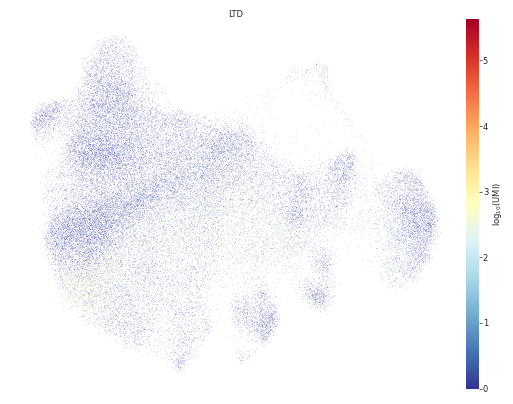

In [36]:
def plot_umi_umap(epitope, ax=None):
    plot = sc.pl.umap(adata[adata.obs[epitope].isna()], 
                         size=12000/len(adata) * 6/6,
                      show=False, ax=ax)
    plot = sc.pl.umap(adata[adata.obs[epitope].notna()], 
                      color=f'log_{epitope}', 
                      cmap='RdYlBu_r', size=12000/len(adata) * 12/6,
                      ax=plot,
                      show=False,)

    plot.set_xlabel(None)
    plot.set_ylabel(None)
    plot.set_title(None)

    plot.legend(loc='upper right', frameon=False)

    sb.despine(ax=plot, left=True, bottom=True)

    cbar = plot.collections[1].colorbar
    cbar.outline.set_visible(False)
    cbar.set_label('log$_{10}$(UMI)')
    cbar.ax.tick_params(length=2, width=0.5, #color=(0.8, 0.8, 0.8, 1.0), 
                        pad=1)
    cbar.ax.yaxis.labelpad = 2 
    
    plot.set_title(f'{epitope[:3]}', pad=0)

plot_umi_umap('LTDEMIAQY')

/opt/conda/envs/dextrademixer/lib/python3.13/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


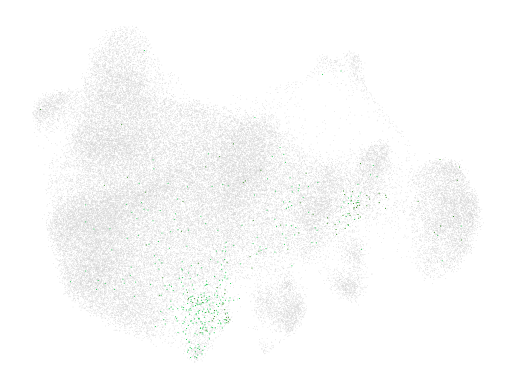

In [37]:
def plot_umap_binding(ax=None):
    plot = sc.pl.umap(adata[adata.obs['Base'].isna()], size=12000/len(adata) * 30/6,
                      show=False, ax=ax)
    
    plot = sc.pl.umap(adata[adata.obs['Base'].notna()], color='Base', size=12000/len(adata) * 60/6,
                      show=False, ax=plot, palette=palette_epitopes)

    plot.set_xlabel(None)
    plot.set_ylabel(None)
    plot.set_title(None)

    plot.legend().remove()  # loc='upper right', frameon=False)

    sb.despine(ax=plot, left=True, bottom=True)

plot_umap_binding()

## Violins

In [ ]:
def pval_to_sign(pval):
    if np.isnan(pval):
        return 'nan'
    if pval < 0.001:
        return '***'
    if pval < 0.01:
        return '**'
    if pval < 0.05:
        return '*'
    return ''

In [39]:
df_prediction

,v_genes,j_genes,donor,clone_id,binding_ct,clonotype_sequence,IR_VJ_1_junction_aa,IR_VDJ_1_junction_aa,P_CloneModel_LTD,CloneModel_LTD,...,annotation_kocher2_LTD,annotation_kocher2_YLQ,annotation_vdjdb_LTD,annotation_vdjdb_YLQ,annotation_tcrvdb_YLQ,annotation_paper_LTD,annotation_paper_YLQ,Epitope,ePytope,Base
0,TRAV26-1 TRBV4-1,TRAJ13 TRBJ1-1,A15,0.0,No binding,CIAPLIPRVTF CASSHVSPYTEAFF,CIAPLIPRVTF,CASSHVSPYTEAFF,4.593395e-21,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LTD,-1.628466,Unspecific
1,TRAV8-3 TRBV5-8,TRAJ48 TRBJ1-1,A29,1.0,No binding,CAVGASFGNEKLTF CASSTIRQGSNTFF,CAVGASFGNEKLTF,CASSTIRQGSNTFF,4.593395e-21,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LTD,-1.875786,Unspecific
2,TRAV13-1 TRBV18,TRAJ45 TRBJ2-7,A15,2.0,No binding,CAASETGGGADGLTF CASSPGYEQYF,CAASETGGGADGLTF,CASSPGYEQYF,3.192026e-17,0.0,...,NaN,NaN,0.0,0.0,NaN,0.0,0.0,LTD,-2.519014,Unspecific
3,TRAV8-6 TRBV7-6,TRAJ23 TRBJ2-1,A29,4.0,No binding,CAVTLLYNQGGKLIF CASSTPGDYTTGNEQFF,CAVTLLYNQGGKLIF,CASSTPGDYTTGNEQFF,4.593395e-21,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LTD,-1.676851,Unspecific
4,TRAV25 TRBV10-3,TRAJ20 TRBJ1-3,A06,5.0,No binding,CAGHPNDYKLSF CAVLGQRDSGNTIYF,CAGHPNDYKLSF,CAVLGQRDSGNTIYF,4.593395e-21,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LTD,-2.126545,Unspecific
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77416,TRAV21 TRBV29-1,TRAJ53 TRBJ1-2,A07,12561.0,No binding,CAVNGDSGGSNYKLTF CSVAGTGFLDYGYTF,CAVNGDSGGSNYKLTF,CSVAGTGFLDYGYTF,6.086243e-08,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,YLQ,-6.274712,Unspecific
77417,TRAV39 TRBV28,TRAJ52 TRBJ1-4,A07,17835.0,No binding,CAVLPLAGGTSYGKLTF CASSDVGTEKLFF,CAVLPLAGGTSYGKLTF,CASSDVGTEKLFF,1.753764e-09,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,YLQ,-4.668442,Unspecific
77418,TRAV21 TRBV9,TRAJ39 TRBJ1-4,A07,15841.0,No binding,CAVAYAGNMLTF CASSGDRGGNEKLFF,CAVRDPPMLTF,CASSGDRGGNEKLFF,1.985799e-07,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,YLQ,-6.232998,Unspecific
77419,TRAV13-2 TRBV4-1,TRAJ34 TRBJ2-1,A07,17845.0,No binding,CAERSYNTDKLIF CASSQVTEQFF,CAERSYNTDKLIF,CASSQVTEQFF,5.521997e-09,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,YLQ,-6.783358,Unspecific


LTDEMIAQY
6.749749337997426e-12
YLQPRTFLL
0.0


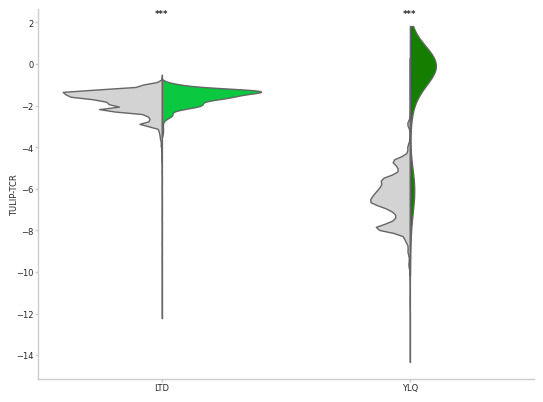

In [40]:
def plot_violin(df, ax=None):
    plot = sb.violinplot(data=df, x='Epitope', order=[el[:3] for el in epitopes],
                  y='ePytope', hue=model, hue_order=['Unspecific', 'Specific'],
                  ax=ax, split=True, inner=None, linewidth=1,
                  palette={'Specific': 'darkgray', 'Unspecific': 'lightgray'}
                 )

    sb.despine(ax=ax)
    plot.grid(False)
    plot.set_ylabel('TULIP-TCR', labelpad=-2)
    plot.set_xlabel(None)
    plot.legend().remove()  # bbox_to_anchor=(0, 1), loc='lower center', ncols=2, frameon=False)
    
    plot.yaxis.set_tick_params(length=2, color=(0.8, 0.8, 0.8, 1.0), pad=1)
    plot.yaxis.set_ticks_position('left')
    
    plot.xaxis.set_tick_params(length=2, color=(0.8, 0.8, 0.8, 1.0), pad=1)
    plot.xaxis.set_ticks_position('bottom')
    
    for i, epitope in enumerate(epitopes):
        df_tmp = df[df['Epitope']==epitope[:3]]
        df_tmp = df_tmp[df_tmp['ePytope'].notna()]
        _, pval = ttest_ind(df_tmp[df_tmp[model]=='Unspecific']['ePytope'].values, 
                            df_tmp[df_tmp[model]=='Specific']['ePytope'].values, )
        print(epitope)
        print(pval)
        
        y_max = plot.get_ylim()[1]
        plot.text(i, y_max, pval_to_sign(pval), ha='center', va='top', weight='bold')
        
    for i, collection in enumerate(plot.collections):
        path = collection.get_paths()[0]
        x_center = path.vertices[:, 0].mean()
        ep = 'LTD' if x_center < 0.5 else 'YLQ'
        spec = 'unspec' if i%2==0 else 'spec'
            
        color = f'{ep}_{spec}'
        collection.set_facecolor(palette_epitopes_ext[color])
    
plot_violin(df_prediction, ax=None)

## Fraction nearest neighbors

In [ ]:
import matplotlib.patches as mpatches

/tmp/ipykernel_2070539/3285151294.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plot.legend().remove()


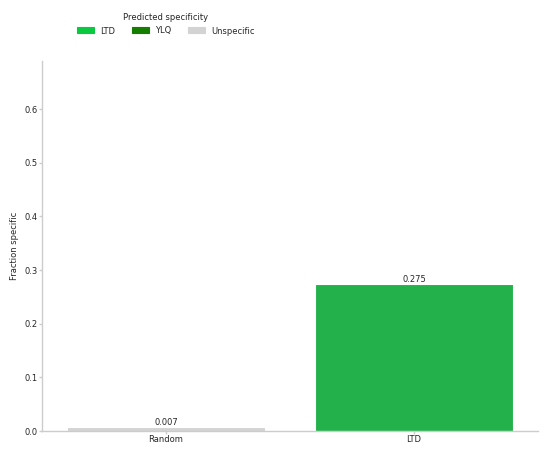

In [42]:

vmax_nn = max(df_nn_ltd['LTD'].max(), df_nn_ylq['YLQ'].max())

legend = {
    'LTD': palette_epitopes['LTD'],
    'YLQ': palette_epitopes['YLQ'],
    'Unspecific': 'lightgray',
}

def plot_nn(df, do_yaxis=True, ax=None):
    epi = 'LTD' if 'LTD' in df['Group'].values else 'YLQ'
    plot = sb.barplot(data=df, x='Group', y=epi, palette=palette_epitopes_ext2[epi], ax=ax)
    #df.plot(kind='bar', stacked=False, ax=ax, 
    #               width=0.9,
    #               color=palette_epitopes_ext2[epi])
    
    sb.despine(ax=ax)
    plot.grid(False)
    plot.set_ylabel('Fraction specific')
    plot.set_xlabel(None)
    plot.legend().remove()
    
    plot.yaxis.set_tick_params(length=2, color=(0.8, 0.8, 0.8, 1.0), pad=1)
    plot.yaxis.set_ticks_position('left')
    
    plot.xaxis.set_tick_params(length=2, color=(0.8, 0.8, 0.8, 1.0), pad=1)
    plot.xaxis.set_ticks_position('bottom')
    
    plot.set_ylim(0, vmax_nn)
    
    if not do_yaxis:
        plot.yaxis.set_visible(False)
        sb.despine(ax=plot, left=True)
        plot.legend().remove()
    else:
        handels = [mpatches.Patch(color=v, label=n) for n, v in legend.items()]
        plot.legend(handles=handels, loc="lower center", ncols=3, 
                    bbox_to_anchor=(0.25, 1.05), title='Predicted specificity',
                    frameon=False)
    
    for container in plot.containers:
        plot.bar_label(container, fmt="%.3f")

plot_nn(df_nn_ltd)

## Purity

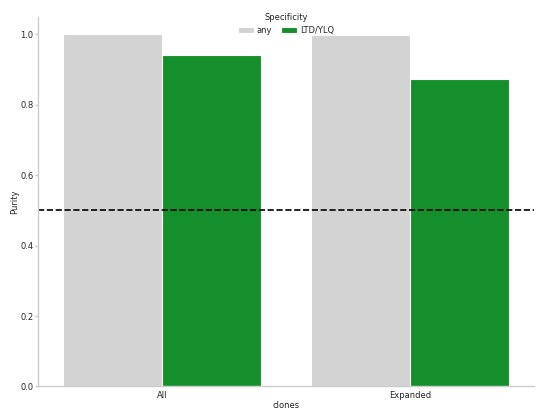

In [43]:
def plot_purity(ax=None):
    plot = sb.barplot(data=df_purity, x='Expanded', hue='Specific', y='Purity', ax=ax,
                     palette=palette_epitopes_ext3)
    
    sb.despine(ax=ax)
    plot.grid(False)
    plot.set_ylabel('Purity', labelpad=1)
    plot.set_xlabel('clones', labelpad=1)
    
    plot.legend(bbox_to_anchor=(0.5, 0.93), loc='lower center', ncols=2, frameon=False, title='Specificity',
                columnspacing=1, handletextpad=0.3)
    
    plot.yaxis.set_tick_params(length=2, color=(0.8, 0.8, 0.8, 1.0), pad=1)
    plot.yaxis.set_ticks_position('left')
    
    plot.xaxis.set_tick_params(length=2, color=(0.8, 0.8, 0.8, 1.0), pad=1)
    
    plot.axhline(0.5, linestyle='--', color='black')
    
plot_purity()

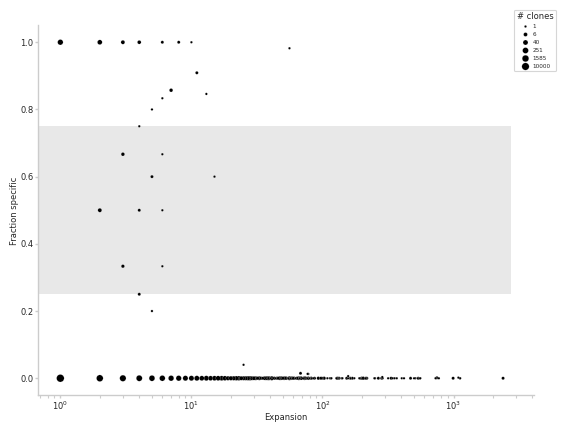

In [44]:
def plot_purity_expansion(df, ax=None):
    plot = sb.scatterplot(data=df, x='Expansion', y='% Pos', size='Log # clones', color='black', sizes=(3, 30), ax=ax)

    band = patches.Rectangle((0, 0.25), plot.get_xlim()[1]*1.1, 0.5, color='lightgray', zorder=0, alpha=0.5, linewidth=0)
    plot.add_patch(band)

    plot.set_xscale('log')

    handles, labels = plot.get_legend_handles_labels()
    plot.legend(handles=handles, labels=[round(10**float(el)) for el in labels], title='# clones',
             bbox_to_anchor=(1.05, 1.05), loc='upper right', handletextpad=0.3, labelspacing=0.5, fontsize='x-small')


    sb.despine(ax=plot)
    
    sb.despine(ax=ax)
    plot.grid(False)
    plot.set_ylabel('Fraction specific', labelpad=1)
    plot.set_xlabel('Expansion', labelpad=1)
    
    plot.yaxis.set_tick_params(length=2, color=(0.8, 0.8, 0.8, 1.0), pad=1)
    plot.yaxis.set_ticks_position('left')
    plot.xaxis.set_tick_params(length=2, color=(0.8, 0.8, 0.8, 1.0), pad=1, which='both')
    plot.xaxis.set_ticks_position('bottom')

plot_purity_expansion(df_purity_all)

## Performance

In [ ]:
palette_model = {
    'LTD_Base': '#d1b770',
    'LTD_CloneModel': '#b38711',
    'YLQ_Base': '#78889f',
    'YLQ_CloneModel': '#1e395f',
}

/tmp/ipykernel_2070539/1136391533.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plot.legend().remove()


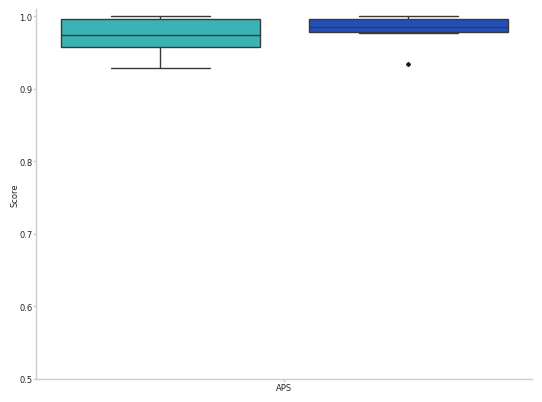

In [46]:
def plot_performance(df_, metric, do_yaxis=True, ax=None):
    df = df_[df_['Metric']==metric].copy()
    df['Epi_Method'] = df['Epitope'] + '_' + df['Method']
    order = [el for el in ['AUC', 'APS', 'Acc', 'F1', 'Precision', 'Recall'] if el in df['Metric'].values]
    order = [el for el in ['F1', 'Precision', 'Recall', 'APS'] if el in df['Metric'].values]
    df['x'] = df['Method'].map({'DextraDemixer': 0, 'DextraDemixer+clone': 0.8})
    df['exp_offset'] = df['Experiment'].map({'first': 0, 'second': 0.2, 'third': 0.4})
    df['epi_offset'] = df['Epitope'].map({'LTD': 0, 'YLQ': 0.1})
    df['x'] = df['x'] + df['exp_offset'] + df['epi_offset']
    
    plot = sb.boxplot(data=df, y='Value', x='Method', 
                      ax=ax, #order=['DextraDemixer', 'DextraDemixer+clone'],
                      palette=palette, flierprops={'marker': 'D', 'markerfacecolor': 'k', 
                                                          'markeredgecolor': 'k', 'markersize': 2}
                 )

    sb.despine(ax=ax)
    plot.grid(False)
    plot.set_ylabel('Score', labelpad=0)
    plot.set_xlabel(None)
    plot.legend().remove()
    
    plot.yaxis.set_tick_params(length=2, color=(0.8, 0.8, 0.8, 1.0), pad=1)
    plot.yaxis.set_ticks_position('left')
    
    #plot.set_xlim((-0.3, 1.6))
    plot.set_xticks([0.5])
    plot.set_xticklabels([metric])
    plot.xaxis.set_tick_params(length=2, color=(0.8, 0.8, 0.8, 1.0), pad=1)
    plot.xaxis.set_ticks_position('bottom')
    plot.set_ylim((-0.05, 1.05))
    plot.set_ylim((0.5, 1.01))
    

    if not do_yaxis:
        plot.yaxis.set_visible(False)
        sb.despine(ax=plot, left=True)  

plot_performance(results_score, 'APS', do_yaxis=True)

## Motifs

findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Ro

findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Ro

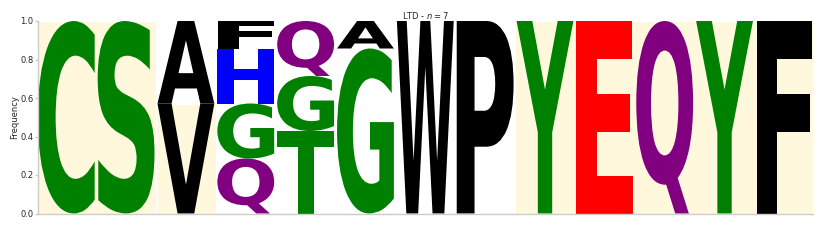

In [47]:
def plot_motifs(epitope, ax=None):   
    seqs = sequences[epitope]
    n_seqs = len(seqs)
    seqs = seqs['cdr3_b'].apply(lambda x: pd.Series(list(x)))
    seqs.columns = [el for el in seqs.columns]
    seqs = seqs.apply(pd.value_counts).transpose() / len(seqs)
    seqs = seqs.fillna(0.0)
    seqs[seqs < 0.10] = 0
    if '-' in seqs.columns:
        seqs = seqs.drop(columns=['-'])
    logo = lm.Logo(seqs, stack_order='small_on_top', color_scheme='chemistry', font_name='Arial Rounded MT Bold', ax=ax)
    plot = logo.ax

    sb.despine(ax=plot)
    plot.set_ylabel('Frequency', labelpad=1)
    plot.set_xticks([])
    plot.set_xticklabels([])
    plot.grid(False)

    if epitope == 'LTD':
        logo.highlight_position_range(pmin=0, pmax=1, color='cornsilk')
        rect = patches.Rectangle((1.5, 0), 1, 4/7, facecolor='cornsilk', zorder=-2)
        plot.add_patch(rect)
        logo.highlight_position_range(pmin=8, pmax=12, color='cornsilk')
    elif epitope == 'YLQ':
        #logo.highlight_position_range(pmin=13, pmax=13, color='cornsilk')
        logo.highlight_position_range(pmin=13, pmax=17, color='cornsilk')

        for p, h in [(10.5, 46/48), (11.5, 46/48)]:
            rect = patches.Rectangle((p, 0), 1, h, facecolor='cornsilk', zorder=-2)
            ax.add_patch(rect)

    plot.yaxis.set_tick_params(length=2, color=(0.8, 0.8, 0.8, 1.0), pad=1)
    plot.yaxis.set_ticks_position('left')
            
    plot.set_title(f'{epitope} - $n={n_seqs}$', pad=0)
    
plot_motifs('LTD')

/tmp/ipykernel_2070539/2737625699.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(), rotation=90)


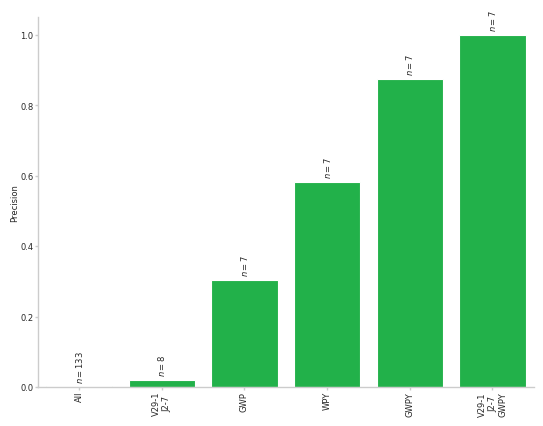

In [48]:
def plot_precision(df, epitope, ax=None):
    plot = sb.barplot(data=df, x='Method', y='Precision', ax=ax, color=palette_epitopes[epitope])
    
    sb.despine(ax=plot)
    plot.set_ylabel('Precision', labelpad=1)
    plot.set_xlabel(None)
    plot.grid(False)

    plot.yaxis.set_tick_params(length=2, color=(0.8, 0.8, 0.8, 1.0), pad=1)
    plot.yaxis.set_ticks_position('left')
    plot.xaxis.set_tick_params(length=2, color=(0.8, 0.8, 0.8, 1.0), pad=1)
    plot.xaxis.set_ticks_position('bottom')
    plot.set_xticklabels(plot.get_xticklabels(), rotation=90)
    
    for i, (val, h) in enumerate(zip(df['n_pos'].values, df['Precision'].values)):
        plot.text(i, h + 0.01 * df['Precision'].max(),
                  f'$n={val}$', rotation=90, weight='bold',
                 ha='center', va='bottom')  # above bars

plot_precision(df_precision_ltd, 'LTD')

# Grid layout

/tmp/ipykernel_2070539/4021991066.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plot.legend(loc='upper right', frameon=False)
/tmp/ipykernel_2070539/4021991066.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plot.legend(loc='upper right', frameon=False)
/opt/conda/envs/dextrademixer/lib/python3.13/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list
/tmp/ipykernel_2070539/3285151294.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plot.legend().remove()
/

LTDEMIAQY
6.749749337997426e-12
YLQPRTFLL
0.0


/tmp/ipykernel_2070539/1136391533.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plot.legend().remove()
/tmp/ipykernel_2070539/1136391533.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plot.legend().remove()
/tmp/ipykernel_2070539/1136391533.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plot.legend().remove()
/tmp/ipykernel_2070539/1136391533.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plot.legend().remove()
findfont: Font family 'Arial Rounded MT Bold' not found.

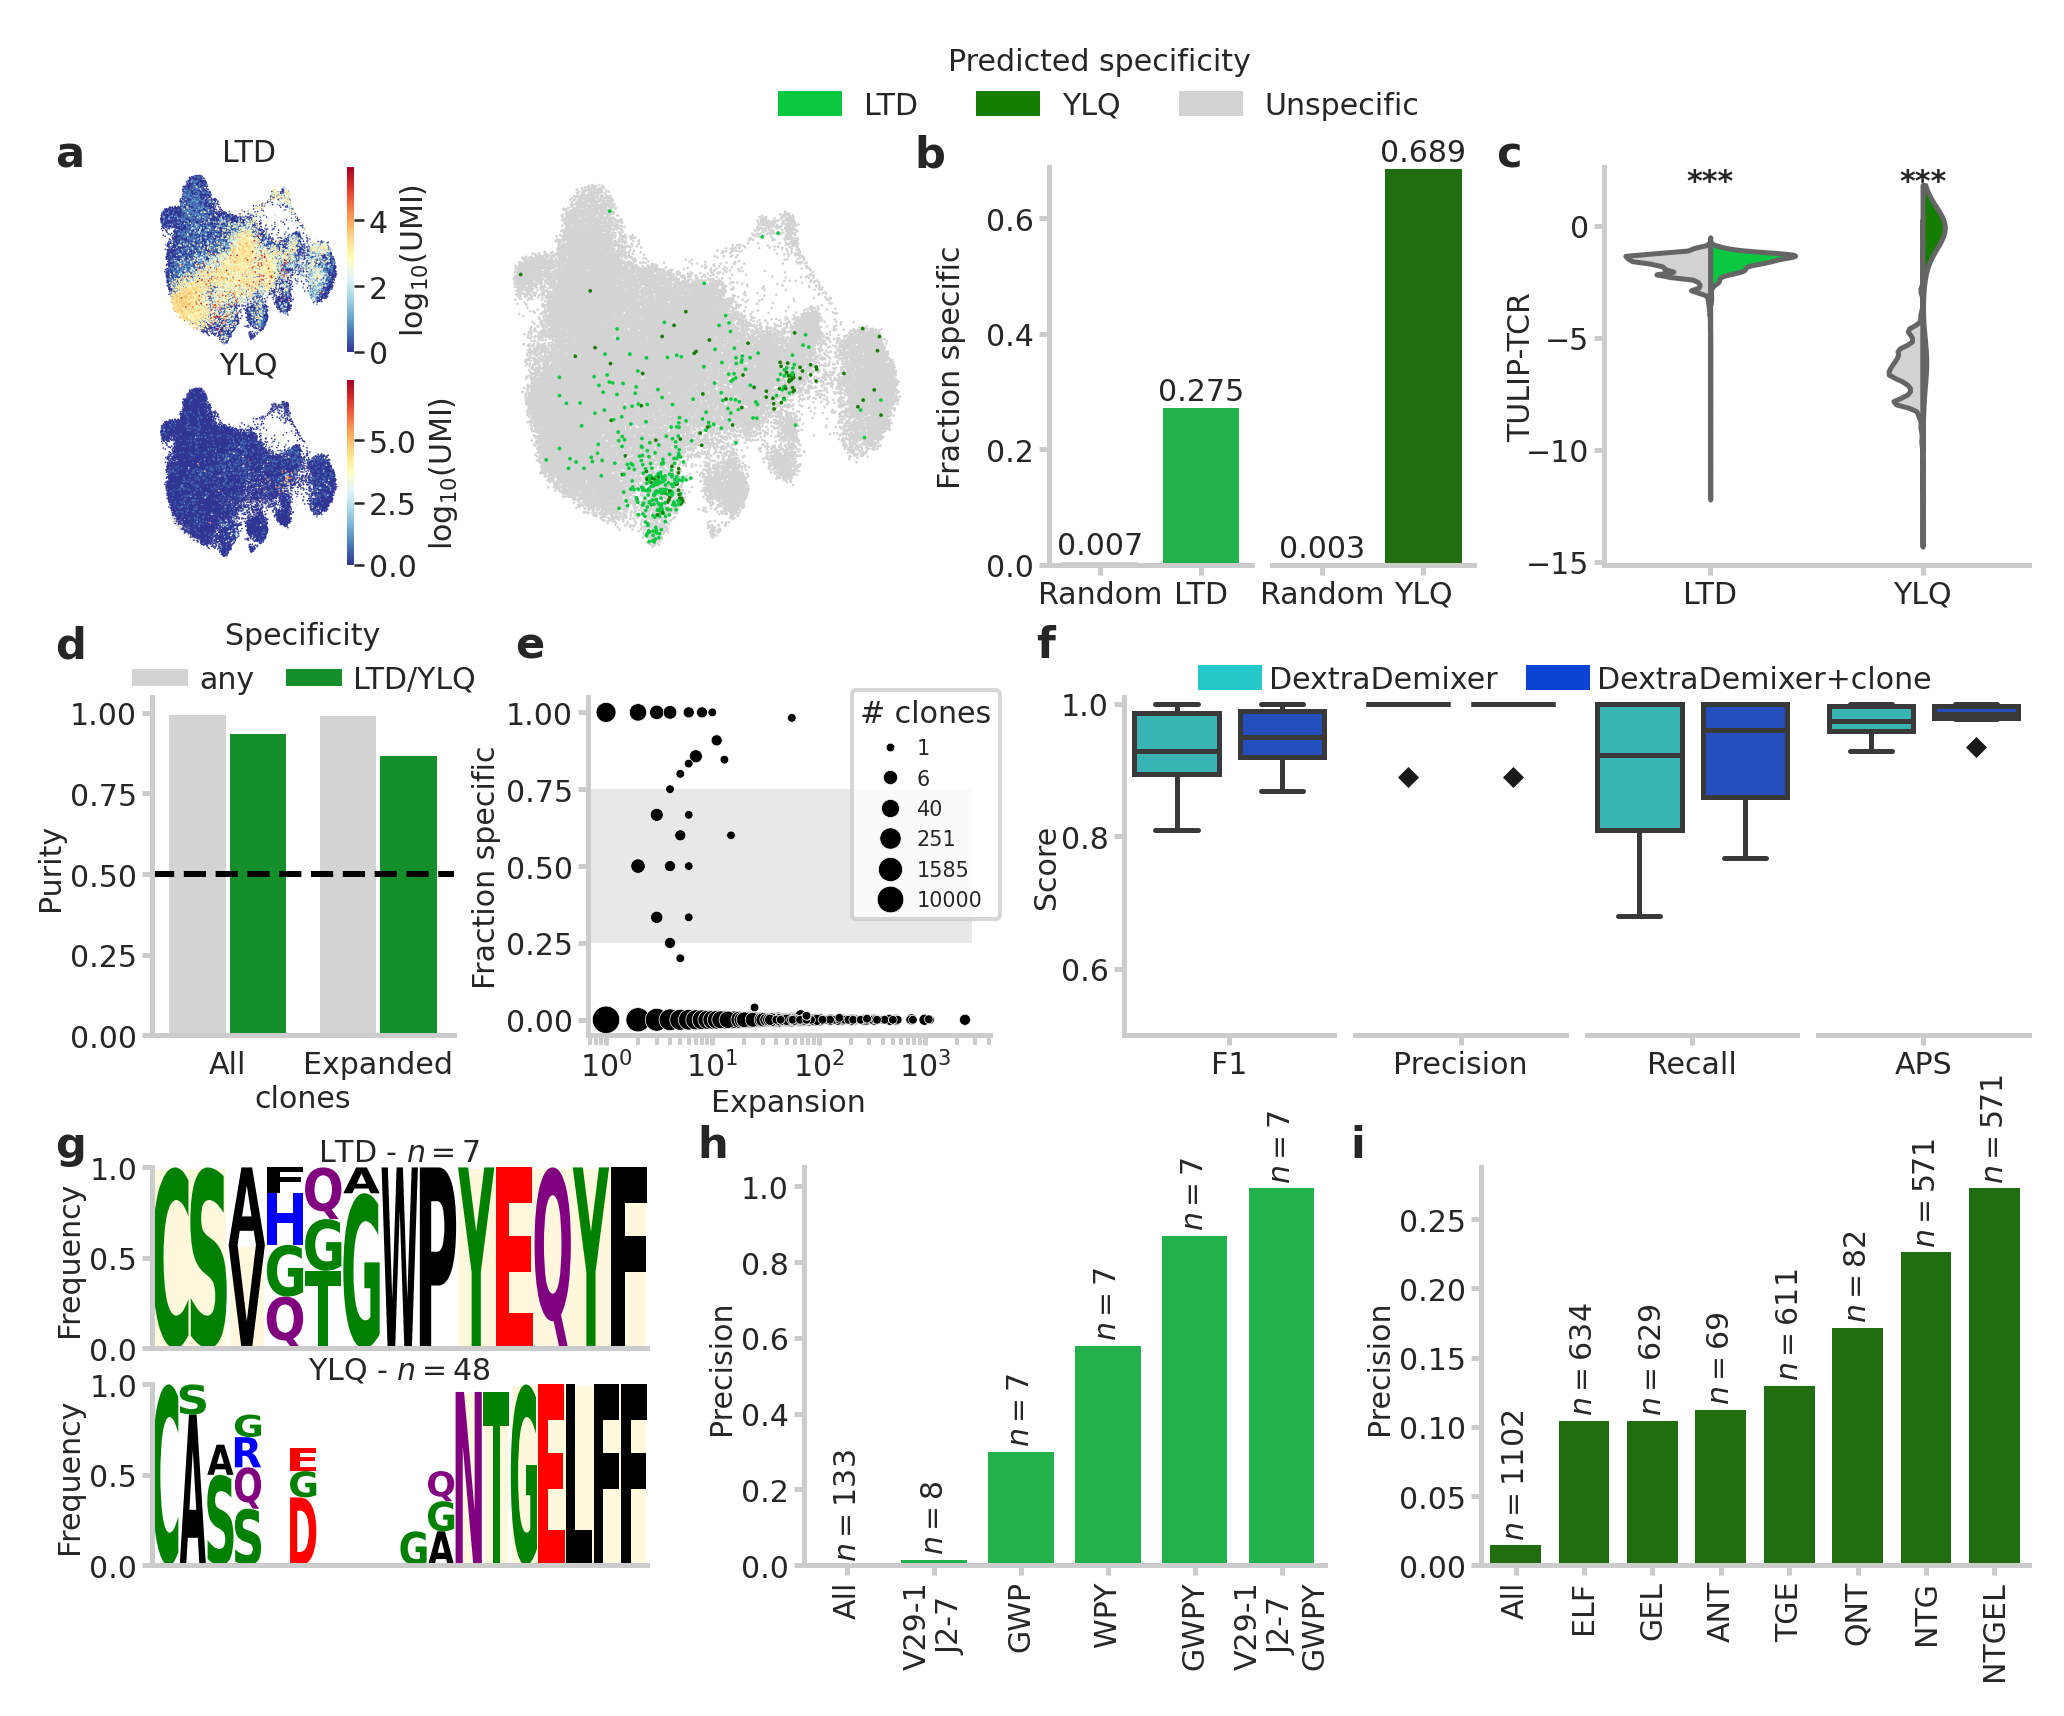

In [49]:
scale = 1
fig = plt.figure(figsize=(TEXT_WIDTH * scale, TEXT_WIDTH * scale * 0.75), #0.65
                 dpi=DPI)

gridspecs = {}

gridspecs["full"] = mpl.gridspec.GridSpec(
    figure=fig,
    nrows=3,
    ncols=1,
    height_ratios=[1, 0.85, 1],
    width_ratios=[1],
    hspace=0.35
)

gridspecs["a-c"] = mpl.gridspec.GridSpecFromSubplotSpec(
    subplot_spec=gridspecs['full'][0],
    nrows=1,
    ncols=4,
    height_ratios=[1],
    width_ratios=[0.5, 1, 1, 1 ],
    hspace=0.1,
    wspace=0.35
)

gridspecs["b"] = mpl.gridspec.GridSpecFromSubplotSpec(
    subplot_spec=gridspecs["a-c"][2],
    nrows=1,
    ncols=2,
    height_ratios=[1],
    width_ratios=[1, 1 ],
    wspace=0.1
)

gridspecs["a12"] = mpl.gridspec.GridSpecFromSubplotSpec(
    subplot_spec=gridspecs["a-c"][0],
    nrows=2,
    ncols=1,
    height_ratios=[1, 1],
    width_ratios=[1],
    hspace=0.15
)

gridspecs["d-f"] = mpl.gridspec.GridSpecFromSubplotSpec(
    subplot_spec=gridspecs['full'][1],
    nrows=1,
    ncols=3,
    height_ratios=[1],
    width_ratios=[0.75, 1, 2.25],
    wspace=0.25,
)

gridspecs["f"] = mpl.gridspec.GridSpecFromSubplotSpec(
    subplot_spec=gridspecs['d-f'][2],
    nrows=1,
    ncols=4,
    height_ratios=[1],
    width_ratios=[2, 2, 2, 2],
    wspace=0.1,
)

gridspecs["g-h"] = mpl.gridspec.GridSpecFromSubplotSpec(
    subplot_spec=gridspecs['full'][2],
    nrows=1,
    ncols=3,
    height_ratios=[1],
    width_ratios=[0.95, 1, 1.05],
    wspace=0.3
)

gridspecs["g"] = mpl.gridspec.GridSpecFromSubplotSpec(
    subplot_spec=gridspecs['g-h'][0],
    nrows=2,
    ncols=1,
    height_ratios=[1, 1],
    width_ratios=[1, ],
    wspace=0.3
)

ax_a1 = fig.add_subplot(gridspecs["a12"][0])
ax_a2 = fig.add_subplot(gridspecs["a12"][1])
ax_a3 = fig.add_subplot(gridspecs["a-c"][1])
ax_b1 = fig.add_subplot(gridspecs["b"][0])
ax_b2 = fig.add_subplot(gridspecs["b"][1])
ax_c = fig.add_subplot(gridspecs["a-c"][3])

ax_d = fig.add_subplot(gridspecs["d-f"][0])
ax_e = fig.add_subplot(gridspecs["d-f"][1])
ax_f1 = fig.add_subplot(gridspecs["f"][0])
ax_f2 = fig.add_subplot(gridspecs["f"][1])
ax_f3 = fig.add_subplot(gridspecs["f"][2])
ax_f4 = fig.add_subplot(gridspecs["f"][3])

ax_g1 = fig.add_subplot(gridspecs["g"][0])
ax_g2 = fig.add_subplot(gridspecs["g"][1])
ax_h1 = fig.add_subplot(gridspecs["g-h"][1])
ax_h2 = fig.add_subplot(gridspecs["g-h"][2])

plot_umi_umap('LTDEMIAQY', ax=ax_a1)
plot_umi_umap('YLQPRTFLL', ax=ax_a2)
plot_umap_binding(ax_a3)

plot_nn(df_nn_ltd, ax=ax_b1)
plot_nn(df_nn_ylq, do_yaxis=False, ax=ax_b2)

plot_violin(df_prediction, ax=ax_c)

plot_purity(ax=ax_d)
plot_purity_expansion(df_purity_all, ax=ax_e)

plot_performance(results_class, 'F1', ax=ax_f1)
plot_performance(results_class, 'Precision', do_yaxis=False, ax=ax_f2)
plot_performance(results_class, 'Recall', do_yaxis=False, ax=ax_f3)
plot_performance(results_score, 'APS', do_yaxis=False, ax=ax_f4)

palette_custom = {'DextraDemixer': palette['DextraDemixer'], 'DextraDemixer+clone': palette['DextraDemixer+clone']}
handles = [mpatches.Patch(color=color, label=label) for label, color in palette_custom.items()]
ax_f2.legend(handles=handles, frameon=False, ncols=2, loc='lower center', bbox_to_anchor=(1, 0.93),
             columnspacing=1, handletextpad=0.3)

plot_motifs('LTD', ax_g1)
plot_motifs('YLQ', ax_g2)
plot_precision(df_precision_ltd, 'LTD', ax=ax_h1)
plot_precision(df_precision_ylq, 'YLQ', ax=ax_h2)

fig.text(0.085, 0.88, 'a', size='x-large', weight='bold')
fig.text(0.44, 0.88, 'b', size='x-large', weight='bold')
fig.text(0.68, 0.88, 'c', size='x-large', weight='bold')
fig.text(0.085, 0.61, 'd', size='x-large', weight='bold')
fig.text(0.275, 0.61, 'e', size='x-large', weight='bold')
fig.text(0.49, 0.61, 'f', size='x-large', weight='bold')
fig.text(0.085, 0.335, 'g', size='x-large', weight='bold')
fig.text(0.35, 0.335, 'h', size='x-large', weight='bold')
fig.text(0.62, 0.335, 'i', size='x-large', weight='bold')

os.makedirs('../../figures', exist_ok=True)
fig.savefig('../../figures/Fig4_kocher.pdf',
           dpi=DPI, bbox_inches='tight')
fig.savefig('../../figures/Fig4_kocher.png',
           dpi=DPI, bbox_inches='tight')
plt.show()

## Supplementary Figures

In [50]:
from matplotlib.lines import Line2D

/tmp/ipykernel_2070539/3295047890.py:33: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  else mpatches.Patch(color=color, label=label, edgecolor='none')


LTDEMIAQY
5.4918088137575864
YLQPRTFLL
60.62628996212479


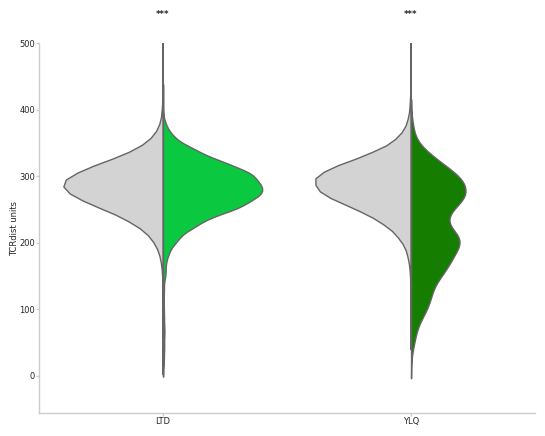

In [51]:
from matplotlib.legend_handler import HandlerBase
from matplotlib.patches import Polygon
import matplotlib.patches as mpatches

class DiagonalSplitPatch:
    def __init__(self, color1, color2):
        self.color1 = color1
        self.color2 = color2


class HandlerDiagonalSplitPatch(HandlerBase):
    def create_artists(self, legend, orig_handle, xdescent, ydescent, width, height, fontsize, trans):
        c1, c2 = orig_handle.color1, orig_handle.color2
        tri1 = Polygon([[xdescent, ydescent], [xdescent + width, ydescent], [xdescent, ydescent + height]], facecolor=c1, edgecolor='none', transform=trans)
        tri2 = Polygon([[xdescent + width, ydescent], [xdescent + width, ydescent + height], [xdescent, ydescent + height]], facecolor=c2, edgecolor='none', transform=trans)
        return [tri1, tri2]


def plot_violin_pairwise(ax=None):
    palette_same = {'same': 'darkgray', 'different': 'lightgray'}
    plot = sb.violinplot(data=df_dist_pairs, hue=f'sameSpec', y='TCRdist', ax=ax, x='Epitope', split=True,
                  order=['LTD', 'YLQ'], hue_order=['different', 'same'], inner=None,
                 palette=palette_same, linewidth=1,
                 )
    
    sb.despine(ax=plot)
    plot.set_ylabel('TCRdist units', labelpad=0)
    plot.grid(False)
    plot.set_xlabel(None)

    handles = [
    DiagonalSplitPatch(palette_epitopes['LTD'], palette_epitopes['YLQ']) if label == 'same'
    else mpatches.Patch(color=color, label=label, edgecolor='none')
    for label, color in palette_same.items()
    ]

    labels = list(palette_same.keys())

    legend_1 = plot.legend(
        handles=handles,
        labels=labels,
        title='Specificity',
        bbox_to_anchor=(1.05, 0.75),
        loc='center left',
        frameon=False,
        handler_map={DiagonalSplitPatch: HandlerDiagonalSplitPatch()}
    )

    plot.add_artist(legend_1)
    
    # handles = [mpatches.Patch(color=color, label=label, edgecolor='none') for label, color in palette_same.items()]
    # legend_1 = plot.legend(handles=handles, title='Specificity', bbox_to_anchor=(1.05, 0.75), loc='center left', frameon=False)
    
    # plot.add_artist(legend_1)
    
    # handles = [mpatches.Patch(color=color, label=label, edgecolor='none') for label, color in palette_epitopes.items()]
    # plot.legend(handles=handles, title='Epitope', bbox_to_anchor=(1.05, 0.25), loc='center left', frameon=False)
    
    
    plot.set_ylim((plot.get_ylim()[0], 500))
    
    for i, epitope in enumerate(epitopes):
        print(epitope)
        tmp = df_dist_pairs[df_dist_pairs['Epitope']==epitope[:3]]
        _, pval = ttest_ind(tmp[tmp['sameSpec']=='different']['TCRdist'].values, 
                            tmp[tmp['sameSpec']=='same']['TCRdist'].values, )
        
        y_max = plot.get_ylim()[1] + 50
        plot.text(i, y_max, pval_to_sign(pval), ha='center', va='top', weight='bold')
        print(tmp[tmp['sameSpec']=='different']['TCRdist'].values.mean() - 
                            tmp[tmp['sameSpec']=='same']['TCRdist'].values.mean())
        
        
    plot.yaxis.set_tick_params(length=2, color=(0.8, 0.8, 0.8, 1.0), pad=1)
    plot.yaxis.set_ticks_position('left')
    
    plot.xaxis.set_tick_params(length=2, color=(0.8, 0.8, 0.8, 1.0), pad=1)
    plot.xaxis.set_ticks_position('bottom')
    
        
    for i, collection in enumerate(plot.collections):
        path = collection.get_paths()[0]
        x_center = path.vertices[:, 0].mean()
        ep = 'LTD' if x_center < 0.5 else 'YLQ'
        spec = 'unspec' if i%2==0 else 'spec'
            
        color = f'{ep}_{spec}'
        collection.set_facecolor(palette_epitopes_ext[color])
        
plot_violin_pairwise(ax=None)

In [52]:
# palette_model_2 = {
#     'LTD': {
#         'DextraDemixer': palette['darkblue'],
#         'DextraDemixer+clone': palette['cyan'],
#     },
#     'YLQ': {
#         'DextraDemixer': palette['darkblue'],
#         'DextraDemixer+clone': palette['cyan'],
#     }
# }

/tmp/ipykernel_2070539/3692147367.py:11: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  plot = sb.scatterplot(data=df, y='Value', x='x', hue='Method', style='Experiment', markers=marker_map,
/tmp/ipykernel_2070539/3692147367.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plot.legend().remove()


,Method,Epitope,Experiment,Baseline,Metric,Value,Epi_Method,x,exp_offset,epi_offset


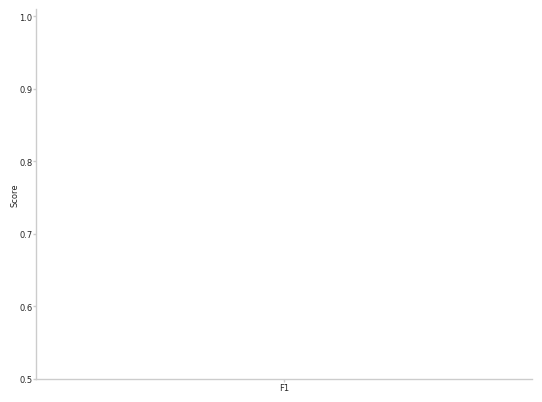

In [53]:
def plot_performance_scatter(df_, metric, epi, do_yaxis=True, ax=None):
    df = df_[(df_['Metric']==metric) & (df_['Epitope']==epi)].copy()
    df['Epi_Method'] = df['Epitope'] + '_' + df['Method']
    order = [el for el in ['F1', 'Precision', 'Recall', 'APS'] if el in df['Metric'].values]
    df['x'] = df['Method'].map({'DextraDemixer': 0, 'DextraDemixer+clone': 0.8})
    df['exp_offset'] = df['Experiment'].map({'first': 0, 'second': 0.15, 'third': 0.3})
    df['epi_offset'] = df['Epitope'].map({'LTD': 0, 'YLQ': 0.1})
    df['x'] = df['x'] + df['exp_offset'] #+ df['epi_offset']
    
    marker_map = {'first': 'o', 'second': '^', 'third': 'v'}
    plot = sb.scatterplot(data=df, y='Value', x='x', hue='Method', style='Experiment', markers=marker_map,
                      ax=ax, #order=['DextraDemixer', 'DextraDemixer+clone'],
                      palette=palette, 
                          s=15, zorder=2
                 )

    sb.despine(ax=ax)
    plot.grid(False)
    plot.set_ylabel('Score', labelpad=0)
    plot.set_xlabel(None)
    plot.legend().remove()
    
    plot.yaxis.set_tick_params(length=2, color=(0.8, 0.8, 0.8, 1.0), pad=1)
    plot.yaxis.set_ticks_position('left')
    
    plot.set_xlim((-0.3, 1.3))
    plot.set_xticks([0.5])
    plot.set_xticklabels([metric])
    plot.xaxis.set_tick_params(length=2, color=(0.8, 0.8, 0.8, 1.0), pad=1)
    plot.xaxis.set_ticks_position('bottom')
    plot.set_ylim((0.5, 1.01))
    

    if not do_yaxis:
        plot.yaxis.set_visible(False)
        sb.despine(ax=plot, left=True)
        
    
    for exp in df['Experiment'].unique():
        x = df[df['Experiment']==exp]['x'].values
        y = df[df['Experiment']==exp]['Value'].values
        plot.plot([x[0], x[1]], [y[0], y[1]], color='lightgrey', alpha=0.75, zorder=1, linewidth=0.75)
    
    return df


plot_performance_scatter(results_score, 'F1', 'YLQ', do_yaxis=True)

/tmp/ipykernel_2070539/3295047890.py:33: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  else mpatches.Patch(color=color, label=label, edgecolor='none')


LTDEMIAQY
5.4918088137575864
YLQPRTFLL
60.62628996212479


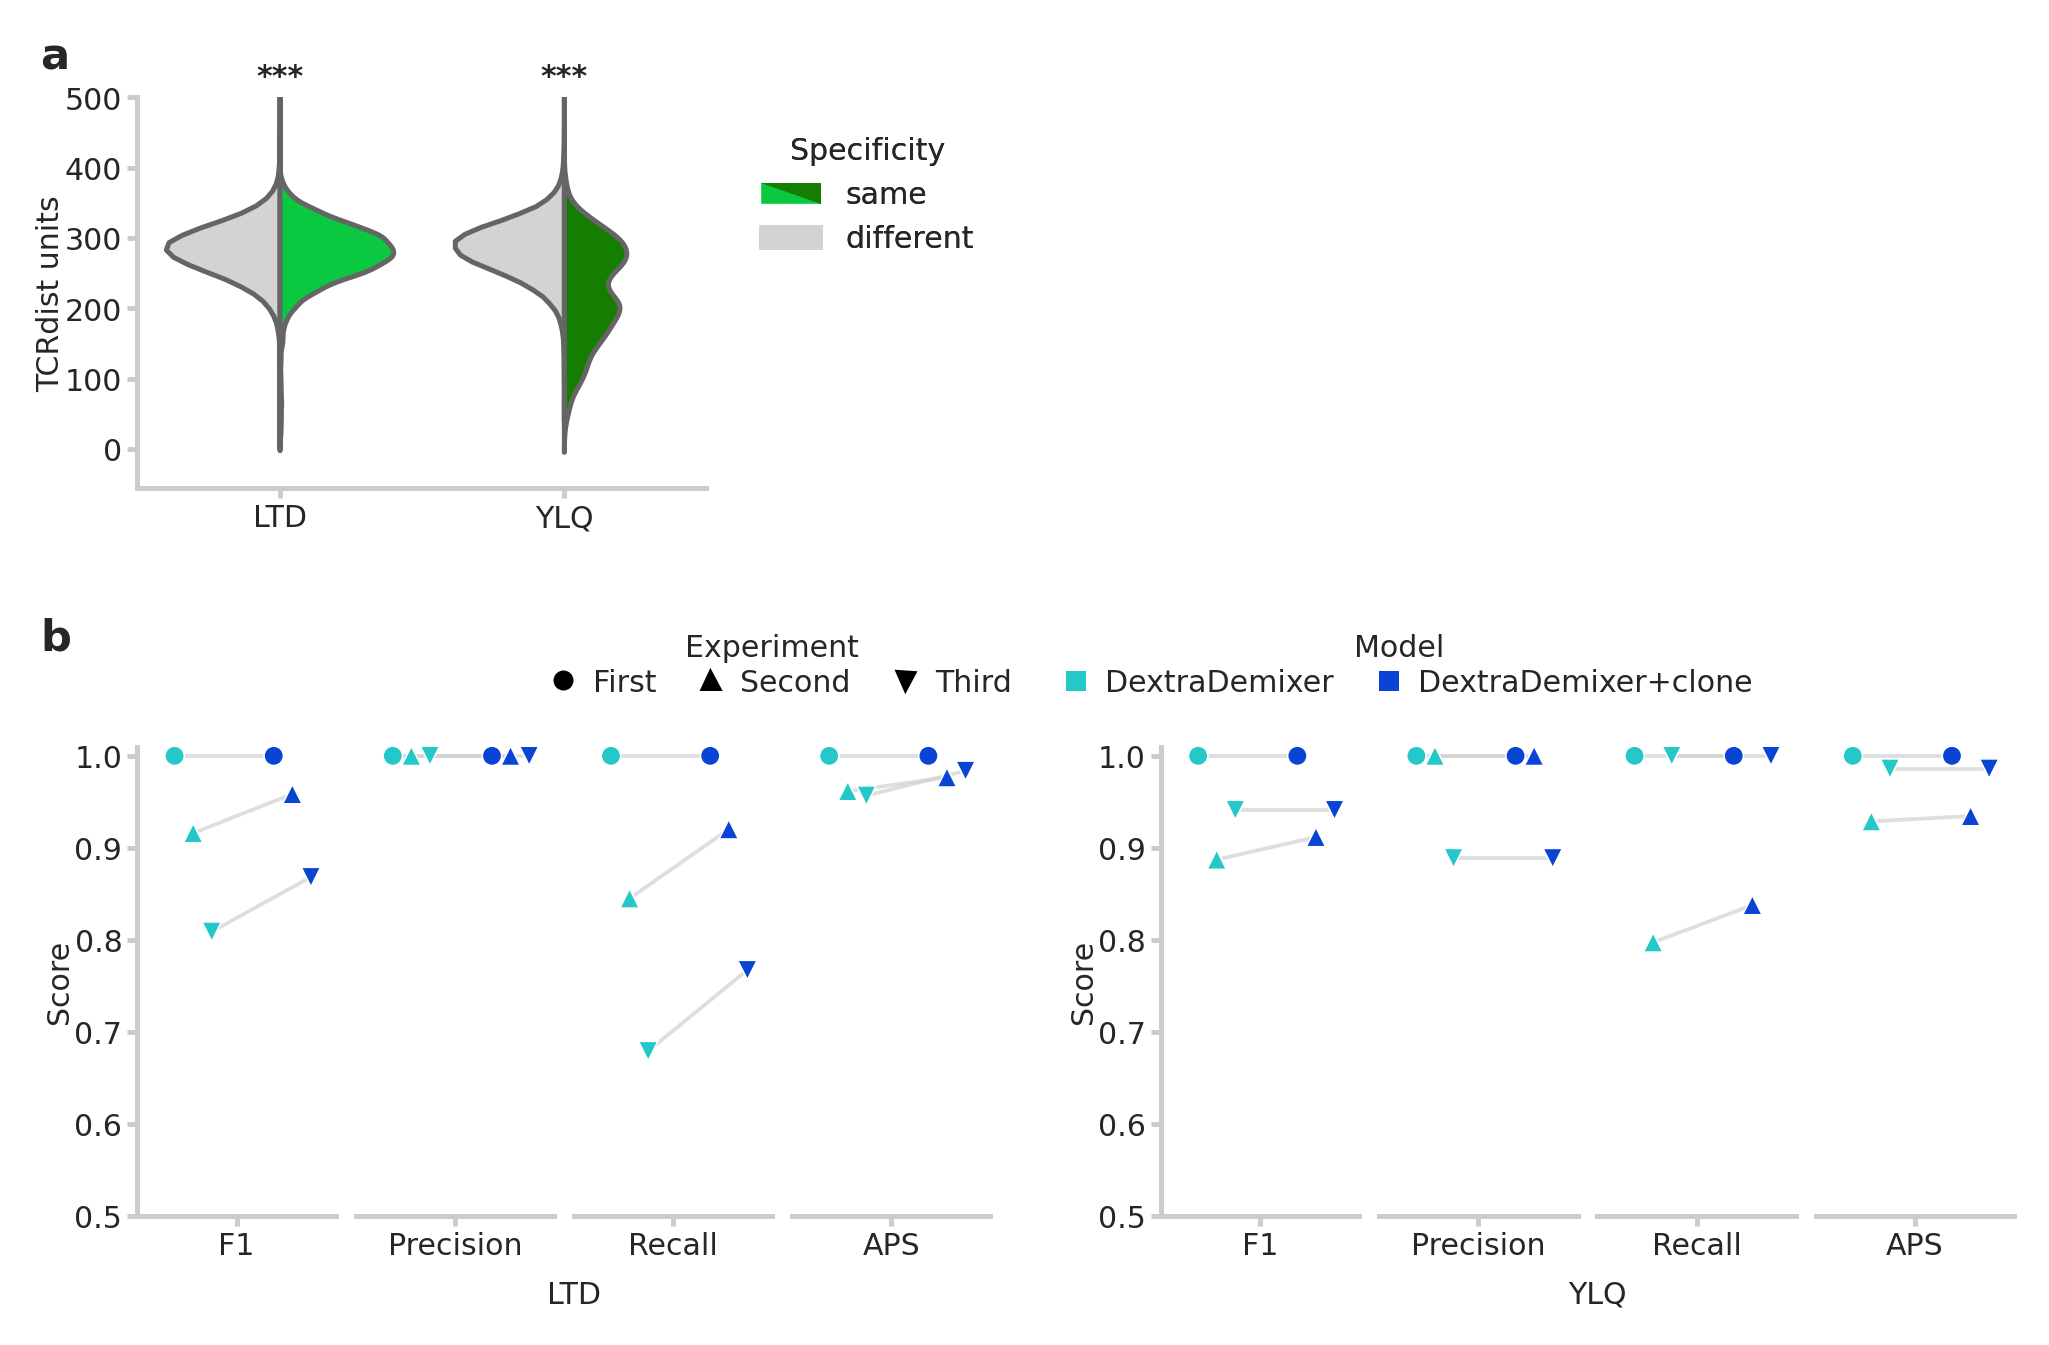

In [54]:
scale = 1
fig = plt.figure(figsize=(TEXT_WIDTH * scale, TEXT_WIDTH * scale * 0.6), #0.65
                 dpi=DPI)

gridspecs = {}

gridspecs["full"] = mpl.gridspec.GridSpec(
    figure=fig,
    nrows=2,
    ncols=1,
    height_ratios=[1, 1.2],
    width_ratios=[1],
    hspace=0.6
)

gridspecs["a"] = mpl.gridspec.GridSpecFromSubplotSpec(
    subplot_spec=gridspecs['full'][0],
    nrows=1,
    ncols=2,
    height_ratios=[1],
    width_ratios=[1, 2],
)

gridspecs["b"] = mpl.gridspec.GridSpecFromSubplotSpec(
    subplot_spec=gridspecs['full'][1],
    nrows=1,
    ncols=2,
    height_ratios=[1],
    width_ratios=[1, 1],
    wspace=0.2
)

gridspecs["b_LTD"] = mpl.gridspec.GridSpecFromSubplotSpec(
    subplot_spec=gridspecs['b'][0],
    nrows=1,
    ncols=4,
    height_ratios=[0.8],
    width_ratios=[1, 1, 1, 1],
    wspace=0.1
)

gridspecs["b_YLQ"] = mpl.gridspec.GridSpecFromSubplotSpec(
    subplot_spec=gridspecs['b'][1],
    nrows=1,
    ncols=4,
    height_ratios=[0.8],
    width_ratios=[1, 1, 1, 1],
    wspace=0.1
)


ax_a1 = fig.add_subplot(gridspecs["a"][0])
ax_a2 = fig.add_subplot(gridspecs["a"][1])

plot_violin_pairwise(ax=ax_a1)
ax_a2.axis(False)


for j, epi in enumerate(['LTD', 'YLQ']):
    for i, m in enumerate(['F1', 'Precision', 'Recall', 'APS']):
        ax_b_tmp = fig.add_subplot(gridspecs[f"b_{epi}"][i])
        results = results_score if i > 2 else results_class
        plot_performance_scatter(results, m, epi, do_yaxis=i==0, ax=ax_b_tmp)
        
        if i == 2:
            if j == 0:
                marker_map = {'First': 'o', 'Second': '^', 'Third': 'v'}
                handles = [Line2D([0], [0], marker=marker, linestyle='', color='black', label=label, markersize=3) 
                           for label, marker in marker_map.items()]
                ax_b_tmp.legend(handles=handles, title="Experiment", bbox_to_anchor=(1., 1.3), loc='upper center', 
                                frameon=False, ncols=3, columnspacing=0.8, handletextpad=0.0, labelspacing=0.2)
                ax_b_tmp.set_xlabel('LTD', x=0.)
                
            if j == 1:
                handles = [Line2D([0], [0], marker='s', color=color, linestyle='', markersize=3, label=label)
                           for label, color in palette_custom.items()]
                ax_b_tmp.legend(handles=handles, title="Model", bbox_to_anchor=(-1., 1.3), loc='upper center', 
                                frameon=False, ncols=3, columnspacing=0.8, handletextpad=0.0, labelspacing=0.2)
                ax_b_tmp.set_xlabel('YLQ', x=0.)


fig.text(0.085, 0.9, 'a', size='x-large', weight='bold')
fig.text(0.085, 0.5, 'b', size='x-large', weight='bold')

#fig.tight_layout()
fig.savefig('../../figures/SuppFig5_kocher.pdf',
           dpi=DPI, bbox_inches='tight')
fig.savefig('../../figures/SuppFig5_kocher.png',
           dpi=DPI, bbox_inches='tight')
plt.show()